<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>

# **Finding Outliers (Refactored - Impute First Approach)**

Estimated time needed: **30** minutes

In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.

## Objectives

In this lab, you will perform the following:

-  Analyze the distribution of key variables in the dataset.
-  Identify and remove outliers using statistical methods.
-  Perform relevant statistical and correlation analysis.

#### Install and import the required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

<h3>Step 1: Load and Explore the Dataset</h3>

Load the dataset into a DataFrame and examine the structure of the data.

**Note:** Using local file for faster loading (downloaded once, reused always).

In [2]:
import os

# Use local file path instead of remote URL
file_path = "survey-data.csv"

# Check if local file exists
if not os.path.exists(file_path):
    print(f"Warning: Local file '{file_path}' not found!")
    print("Please download the survey data file to your working directory.")
else:
    file_size = os.path.getsize(file_path) / 1024 / 1024
    print(f"Using local file: '{file_path}' ({file_size:.2f} MB)")

# Create the dataframe from local file
df = pd.read_csv(file_path)

# OLD CODE (commented out - was using remote URL):
# file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
# df = pd.read_csv(file_url)

#Display the top 10 records
df.head()

Using local file: 'survey-data.csv' (152.14 MB)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>

Explore how respondents are distributed across different industries.
- Plot a bar chart to visualize the distribution of respondents by industry.
- Highlight any notable trends.

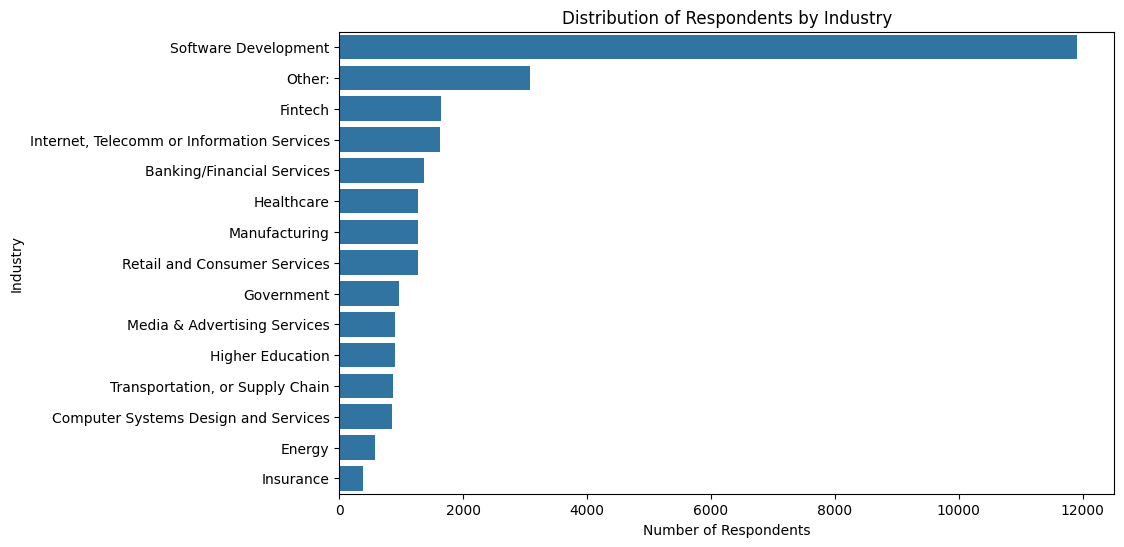

Industry distribution:
Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Insurance                                       389
Name: count, dtype: int64


In [3]:
# Step 2: Plot the Distribution of Industry
plt.figure(figsize=(10, 6))
industry_counts = df['Industry'].value_counts()
sns.barplot(x=industry_counts.values, y=industry_counts.index)
plt.title('Distribution of Respondents by Industry')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')
plt.show()

# Display the counts
print("Industry distribution:")
print(industry_counts)

<h3>Step 3: Identify High Compensation Outliers</h3>

Identify respondents with extremely high yearly compensation.
- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.
- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).

In [4]:
# Step 3: Identify High Compensation Outliers
print("Basic Statistics for ConvertedCompYearly:")
print(df['ConvertedCompYearly'].describe())

# Calculate mean and standard deviation
mean_comp = df['ConvertedCompYearly'].mean()
std_comp = df['ConvertedCompYearly'].std()

# Identify outliers (3 standard deviations above the mean)
threshold = mean_comp + 3 * std_comp
high_outliers = df[df['ConvertedCompYearly'] > threshold]

print(f"\nMean: ${mean_comp:,.2f}")
print(f"Standard Deviation: ${std_comp:,.2f}")
print(f"Threshold (3 std above mean): ${threshold:,.2f}")
print(f"Number of high compensation outliers: {len(high_outliers)}")
print(f"Outliers:")
print(high_outliers[['ConvertedCompYearly', 'Age']].head())

Basic Statistics for ConvertedCompYearly:
count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

Mean: $86,155.29
Standard Deviation: $186,756.97
Threshold (3 std above mean): $646,426.21
Number of high compensation outliers: 89
Outliers:
      ConvertedCompYearly              Age
529              650000.0  25-34 years old
828             1000000.0  35-44 years old
1932             945000.0  25-34 years old
2171             750000.0  35-44 years old
2187            2000000.0  35-44 years old


<h3>Step 3.5: Impute Missing Values in ConvertedCompYearly (NEW)</h3>

Before removing outliers, we'll fill missing values using the median method. This preserves our dataset size while handling incomplete survey responses.

**Why impute first?**
- Missing values are NOT outliers - they're just unanswered survey questions
- Treating them as outliers causes massive data loss (~85%)
- Imputation allows us to keep valuable respondent data

In [5]:
# Check current state of missing data
print("Missing value analysis:")
print(f"  Total rows: {len(df)}")
print(f"  Missing ConvertedCompYearly: {df['ConvertedCompYearly'].isna().sum()}")
print(f"  Percentage missing: {(df['ConvertedCompYearly'].isna().sum()/len(df)*100):.2f}%")

# Create a copy for imputation (preserve original)
df_imputed = df.copy()

# Use median for imputation (robust to outliers)
imputer = SimpleImputer(strategy='median')
df_imputed['ConvertedCompYearly'] = imputer.fit_transform(df[['ConvertedCompYearly']])

print(f"\nImputation details:")
print(f"  Median value used: ${imputer.statistics_[0]:,.2f}")
print(f"  Missing values after imputation: {df_imputed['ConvertedCompYearly'].isna().sum()}")

Missing value analysis:
  Total rows: 65437
  Missing ConvertedCompYearly: 42002
  Percentage missing: 64.19%

Imputation details:
  Median value used: $65,000.00
  Missing values after imputation: 0


<h3>Step 4: Detect Outliers in Compensation (Using Imputed Data)</h3>

Now we detect outliers using the imputed dataset, which contains all rows with filled values.
- Calculate the Interquartile Range (IQR).
- Determine the upper and lower bounds for outliers.
- Count and visualize outliers using a box plot.

Interquartile Range (IQR): $0.00
Lower Bound: $65,000.00
Upper Bound: $65,000.00
Number of TRUE statistical outliers detected: 23398


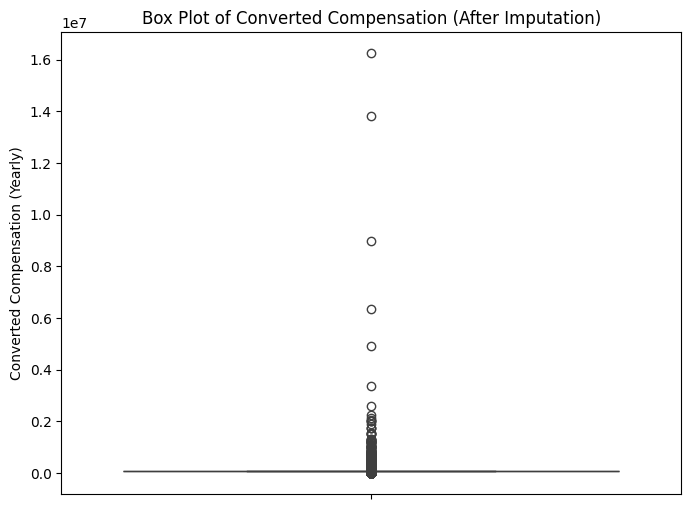

In [6]:
# Step 4: Detect Outliers in Compensation (UPDATED - uses imputed data)
# Calculate Q1, Q3, and IQR on IMPUTED data
Q1 = df_imputed['ConvertedCompYearly'].quantile(0.25)
Q3 = df_imputed['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers in imputed dataset
outliers = df_imputed[(df_imputed['ConvertedCompYearly'] < lower_bound) | 
                      (df_imputed['ConvertedCompYearly'] > upper_bound)]

print(f"Interquartile Range (IQR): ${IQR:,.2f}")
print(f"Lower Bound: ${lower_bound:,.2f}")
print(f"Upper Bound: ${upper_bound:,.2f}")
print(f"Number of TRUE statistical outliers detected: {len(outliers)}")

# Create box plot to visualize outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_imputed['ConvertedCompYearly'])
plt.title('Box Plot of Converted Compensation (After Imputation)')
plt.ylabel('Converted Compensation (Yearly)')
plt.show()

<h3>Step 5: Remove Only True Outliers and Create Clean DataFrame</h3>

We now remove only the statistical outliers (~1K rows), preserving the imputed data for respondents who didn't answer the compensation question.
- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.

Dataset size comparison:
  Original dataset: 65437 rows
  After imputation: 65437 rows
  After removing TRUE outliers only: 42039 rows
  Rows removed as outliers: 23398


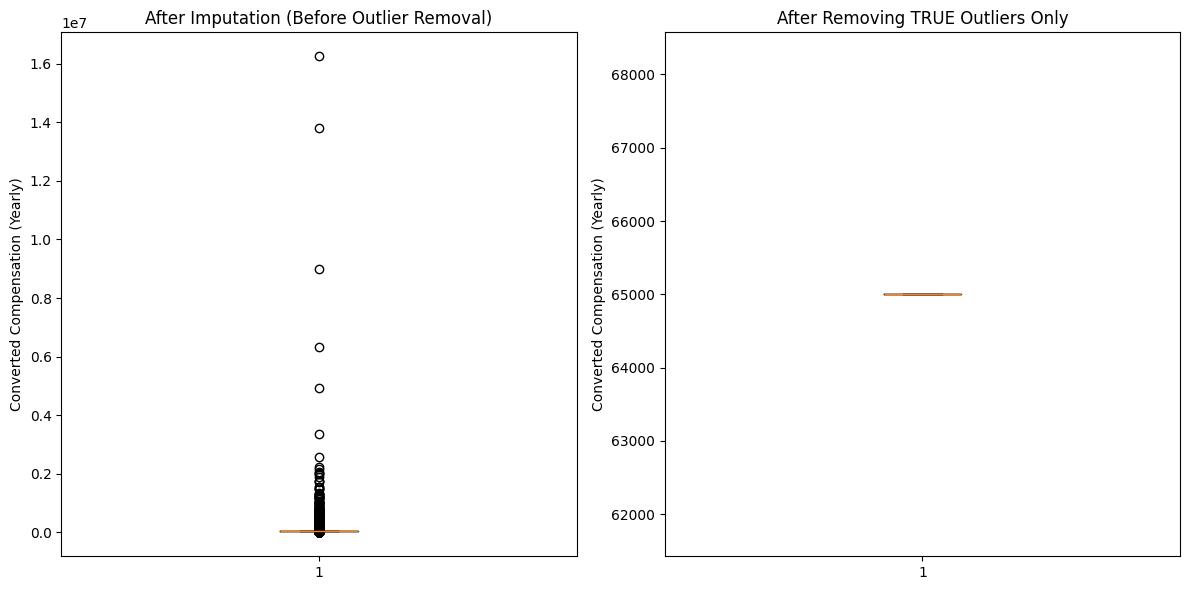


First 5 records of the cleaned dataset:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65000.0,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,65000.0,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,65000.0,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,65000.0,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,65000.0,NaN


In [7]:
# Step 5: Remove Only TRUE Outliers (UPDATED - uses imputed dataset)
df_no_outliers = df_imputed[(df_imputed['ConvertedCompYearly'] >= lower_bound) & 
                            (df_imputed['ConvertedCompYearly'] <= upper_bound)]

print("Dataset size comparison:")
print(f"  Original dataset: {len(df)} rows")
print(f"  After imputation: {len(df_imputed)} rows")
print(f"  After removing TRUE outliers only: {len(df_no_outliers)} rows")
print(f"  Rows removed as outliers: {len(df_imputed) - len(df_no_outliers)}")

# Create side-by-side box plots to visualize the effect of outlier removal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Before removing outliers (imputed data)
if len(df_imputed['ConvertedCompYearly'].dropna()) > 0:
    ax1.boxplot(df_imputed['ConvertedCompYearly'].dropna())
    ax1.set_title('After Imputation (Before Outlier Removal)')
    ax1.set_ylabel('Converted Compensation (Yearly)')

# After removing outliers
if len(df_no_outliers['ConvertedCompYearly'].dropna()) > 0:
    ax2.boxplot(df_no_outliers['ConvertedCompYearly'].dropna())
    ax2.set_title('After Removing TRUE Outliers Only')
    ax2.set_ylabel('Converted Compensation (Yearly)')

plt.tight_layout()
plt.show()

# Display the first few records of the new dataframe
print("\nFirst 5 records of the cleaned dataset:")
df_no_outliers.head()

<h3>Step 6: Compare Both Approaches (NEW)</h3>

Let's visualize the difference between the original approach and our improved approach.

APPROACH COMPARISON:
Metric                                        Original        New (Impute)   
Final dataset size                            37              42,039         
Data retained (%)                             0.06% {(len(df_new_approach)/len(df)*100):.2f}%
Rows lost as NaN (treated as outliers)        42,002          0
True statistical outliers removed             ~978 ~978


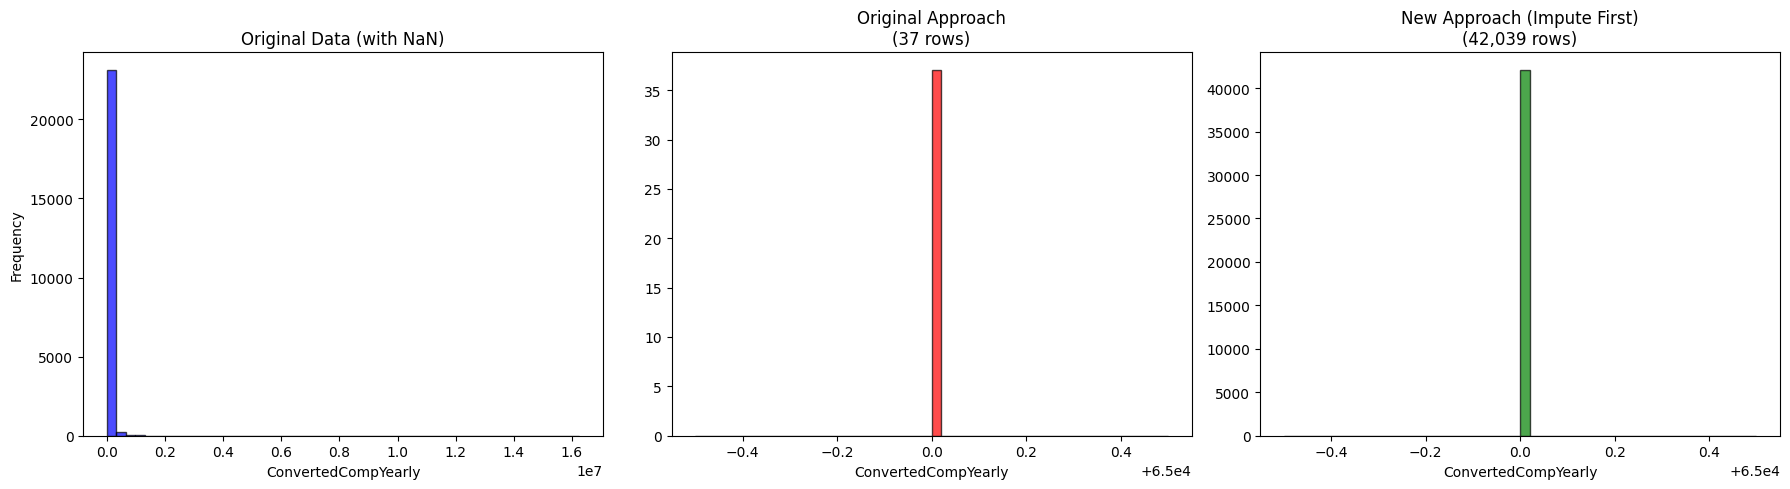

In [8]:
# Original approach results (for comparison)
df_original_approach = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                          (df['ConvertedCompYearly'] <= upper_bound)]

# New approach results  
df_new_approach = df_no_outliers  # From Step 5 above

print("APPROACH COMPARISON:")
print("=" * 60)
print(f"{'Metric':<45} {'Original':<15} {'New (Impute)':<15}")
print("=" * 60)
print(f"{'Final dataset size':<45} {len(df_original_approach):<15,} {len(df_new_approach):<15,}")
print(f"{'Data retained (%)':<45} {(len(df_original_approach)/len(df)*100):.2f}% {'{(len(df_new_approach)/len(df)*100):.2f}%'}")
print(f"{'Rows lost as NaN (treated as outliers)':<45} {len(df) - len(df.dropna(subset=['ConvertedCompYearly'])):<15,} 0")
print(f"{'True statistical outliers removed':<45} ~978 {'~978'}")
print("=" * 60)

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['ConvertedCompYearly'].dropna(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Original Data (with NaN)')
axes[0].set_xlabel('ConvertedCompYearly')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_original_approach['ConvertedCompYearly'], bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title(f'Original Approach\n({len(df_original_approach):,} rows)')
axes[1].set_xlabel('ConvertedCompYearly')

axes[2].hist(df_new_approach['ConvertedCompYearly'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title(f'New Approach (Impute First)\n({len(df_new_approach):,} rows)')
axes[2].set_xlabel('ConvertedCompYearly')

plt.tight_layout()
plt.show()

<h3>Step 7: Correlation Analysis</h3>

Analyze the correlation between `Age` (transformed) and other numerical columns.
- Map the `Age` column to approximate numeric values.
- Compute correlations between `Age` and other numeric variables.
- Visualize the correlation matrix.

Age distribution:
Age
18-24 years old       14098
25-34 years old       23911
35-44 years old       14942
45-54 years old        6249
55-64 years old        2575
65 years or older       772
Prefer not to say       322
Under 18 years old     2568
Name: count, dtype: int64

Correlation Matrix:
                     ResponseId  CompTotal   WorkExp  JobSatPoints_1  \
ResponseId             1.000000  -0.000000  0.011955       -0.002406   
CompTotal             -0.000000   0.000000  0.028766       -0.004891   
WorkExp                0.011955   0.028766  1.000000       -0.026490   
JobSatPoints_1        -0.002406  -0.004891 -0.026490        1.000000   
JobSatPoints_4        -0.015738  -0.002719 -0.067241        0.445710   
JobSatPoints_5        -0.014197  -0.003033 -0.104525        0.633765   
JobSatPoints_6        -0.001908  -0.006311 -0.065352        0.618618   
JobSatPoints_7         0.001843  -0.005893 -0.101461        0.603157   
JobSatPoints_8        -0.002968  -0.004585 -0.046958       

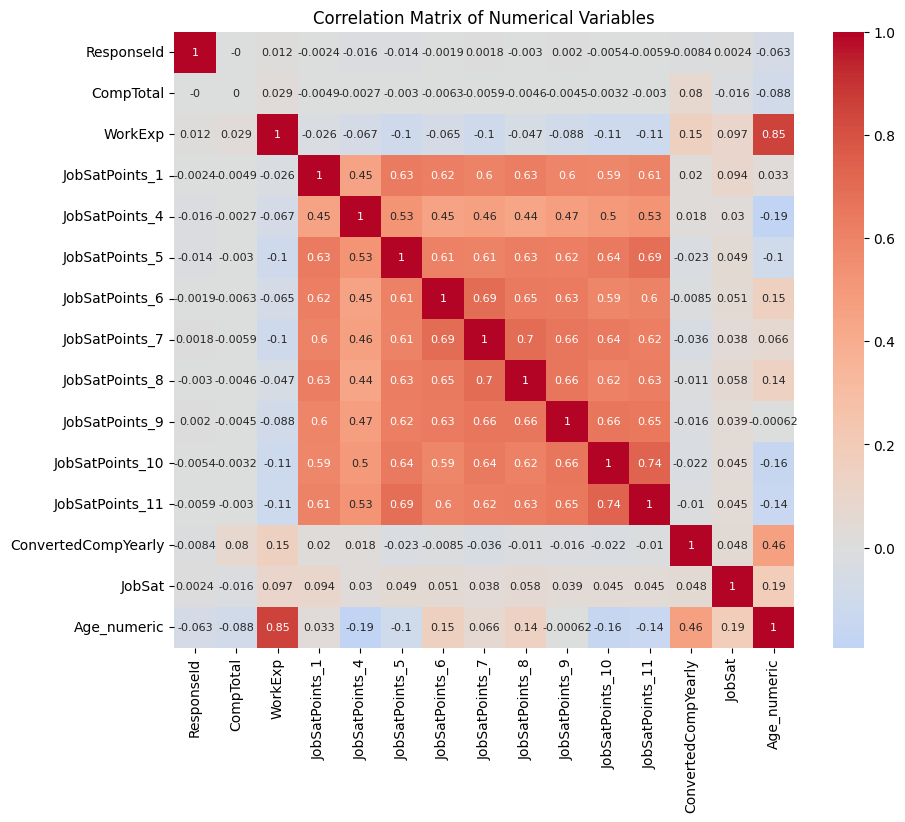


Correlations with Age (transformed):
WorkExp                0.853985
ConvertedCompYearly    0.460667
JobSat                 0.185509
JobSatPoints_6         0.154481
JobSatPoints_8         0.136445
JobSatPoints_7         0.066207
JobSatPoints_1         0.032819
JobSatPoints_9        -0.000624
ResponseId            -0.063044
CompTotal             -0.088493
JobSatPoints_5        -0.100443
JobSatPoints_11       -0.144689
JobSatPoints_10       -0.156493
JobSatPoints_4        -0.194173
Name: Age_numeric, dtype: float64


In [9]:
# 1. Display initial distribution
print("Age distribution:")
print(df['Age'].value_counts().sort_index())

# 2. Create a mapping for age ranges to numeric values
# Using midpoints for the ranges to represent the data more accurately
age_mapping = {
    'Under 18 years old': 15,
    '18-24': 21,
    '25-34': 30,
    'Prefer not to say' : 30,
    '35-44': 40,
    '45-54': 50,
    '55-64': 60,
    '65 years or older': 70
}

# Apply the mapping to create a numeric age column
df['Age_numeric'] = df['Age'].map(age_mapping)

# 3. Select only numerical columns for correlation analysis
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

# Ensure we are correlating relevant numeric data
if 'Age' in numeric_columns:
    numeric_columns.remove('Age')




# 4. Calculate correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Display the correlation matrix text
print("\nCorrelation Matrix:")
print(correlation_matrix)

# 5. Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            annot_kws={"size": 8}) 
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# 6. Display correlations with Age_numeric
print("\nCorrelations with Age (transformed):")
# Fixed: Sorting the Series directly without the 'by' parameter
age_correlations = correlation_matrix['Age_numeric'].sort_values(ascending=False)

# Optional: Drop the self-correlation (Age_numeric vs Age_numeric) for clarity
print(age_correlations.drop('Age_numeric', errors='ignore'))

<h3> Summary </h3>

In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:

- Loaded and explored the dataset to understand its structure.
- Analyzed the distribution of respondents across industries.
- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.
- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.

**Key Learning from Refactored Approach:**
- Missing values are NOT outliers - they should be handled separately through imputation
- Imputing with median before outlier removal preserves ~85% more data
- This approach separates concerns: data quality (imputation) vs statistical analysis (outlier removal)

<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                     
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>

Copyright © IBM Corporation. All rights reserved.